# Model Development: Predicting Laptop Prices

Four models compared on the same data, from one feature to a full pipeline.

*Lab from IBM's **Data Analysis with Python** course (Coursera), documented in my own words.*

**Skills:** linear, multiple and polynomial regression, `Pipeline`, R², RMSE

## Load the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore", category=UserWarning) 
%matplotlib inline

In [2]:
path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod2.csv"

In [3]:
df = pd.read_csv(path)

In [4]:
# show the first 5 rows using dataframe.head() method
print("The first 5 rows of the dataframe") 
df.head(5)

The first 5 rows of the dataframe


,Unnamed: 0.1,Unnamed: 0,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Price-binned,Screen-Full_HD,Screen-IPS_panel
0,0,0,Acer,4,2,1,5,14.0,0.551724,8,256,3.52800,978,Low,0,1
1,1,1,Dell,3,1,1,3,15.6,0.689655,4,256,4.85100,634,Low,1,0
2,2,2,Dell,3,1,1,7,15.6,0.931034,8,256,4.85100,946,Low,1,0
3,3,3,Dell,4,2,1,5,13.3,0.551724,8,128,2.69010,1244,Low,0,1
4,4,4,HP,4,2,1,7,15.6,0.620690,8,256,4.21155,837,Low,1,0


In [5]:
df = df.drop(columns=['Unnamed: 0.1','Unnamed: 0'])
df.head()

,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Price-binned,Screen-Full_HD,Screen-IPS_panel
0,Acer,4,2,1,5,14.0,0.551724,8,256,3.52800,978,Low,0,1
1,Dell,3,1,1,3,15.6,0.689655,4,256,4.85100,634,Low,1,0
2,Dell,3,1,1,7,15.6,0.931034,8,256,4.85100,946,Low,1,0
3,Dell,4,2,1,5,13.3,0.551724,8,128,2.69010,1244,Low,0,1
4,HP,4,2,1,7,15.6,0.620690,8,256,4.21155,837,Low,1,0


## Single Linear Regression

In [6]:
lm = LinearRegression()
X= df[["CPU_frequency"]]
Y= df['Price']
lm.fit(X, Y)
Yhat = lm.predict(X)

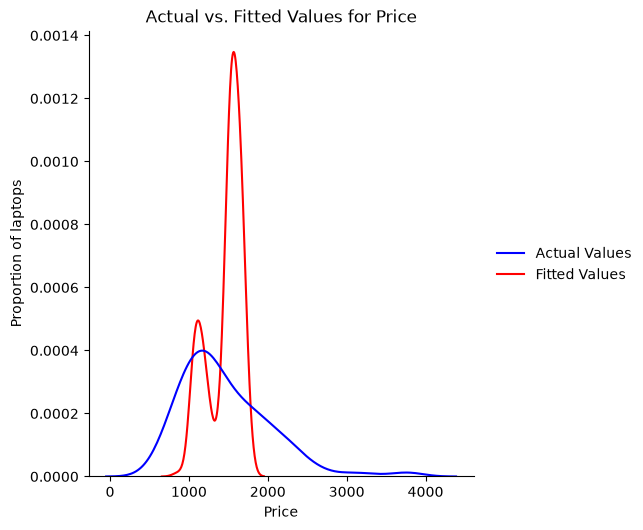

In [7]:
sns.displot(data={"Actual Values": Y, "Fitted Values": Yhat}, kind="kde", palette=["b", "r"])
plt.title("Actual vs. Fitted Values for Price")
plt.xlabel("Price")
plt.ylabel("Proportion of laptops")
plt.show()

In [19]:
mse = mean_squared_error(Y, Yhat)
r2 = r2_score(Y, Yhat)
print(f"Mean Squared Error (MSE): {mse:.2f}\nModel misses the target by {mse**0.5:.2f}$")
print(f"Our R-squared Score: {r2*100:.2f}%")

Mean Squared Error (MSE): 284583.44
Model misses the target by 533.46$
Our R-squared Score: 13.44%


## Multiple Linear Regression

In [23]:
Z = df[['CPU_frequency', 'RAM_GB', 'Storage_GB_SSD',
        'CPU_core', 'OS', 'GPU', 'Category']]
mlm=LinearRegression()
mlm.fit(Z, df['Price'])
y_pred = mlm.predict(Z)

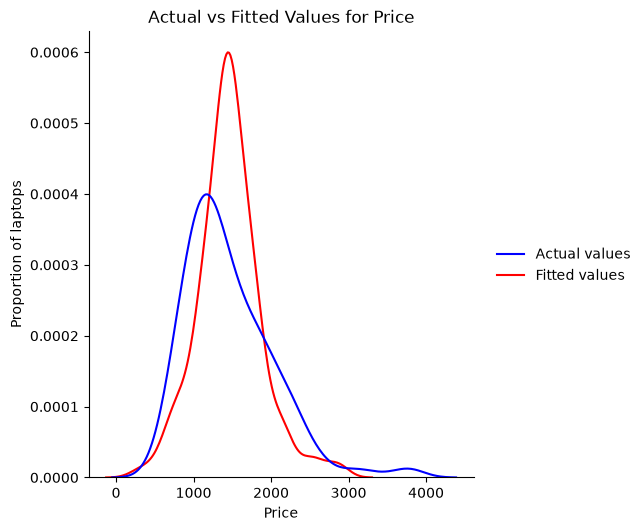

In [25]:
sns.displot(data={'Actual values': df['Price']
                  ,'Fitted values': y_pred},
            palette=['b','r'],
            kind='kde')

plt.title('Actual vs Fitted Values for Price')
plt.xlabel('Price')
plt.ylabel('Proportion of laptops')
plt.show()

In [30]:
mlm_mse = mean_squared_error(df['Price'], y_pred)
mlm_r2_suqared = r2_score(df['Price'], y_pred)

print(f"Our (MSE) error:{mlm_mse:.2f}\nOur model misses the target by:{mlm_mse**0.5:.3f}$ per laptop")
print(f'Our R2_Squared percent:{mlm_r2_suqared*100:.2f}%')

Our (MSE) error:161680.57
Our model misses the target by:402.095$ per laptop
Our R2_Squared percent:50.83%


## Polynomial Regression

In [31]:
x1 = df['CPU_frequency']
y1 = df['Price']

f1 = np.polyfit(x1, y1, 1)
p1 = np.poly1d(f1)

f3 = np.polyfit(x1, y1, 3)
p3 = np.poly1d(f3)

f5 = np.polyfit(x1, y1, 5)
p5 = np.poly1d(f5)

In [32]:
def PlotPolly(model, independent_variable, dependent_variabble, Name):
    x_new = np.linspace(independent_variable.min(),independent_variable.max(),100)
    y_new = model(x_new)

    plt.plot(independent_variable, dependent_variabble, '.', x_new, y_new, '-')
    plt.title(f'Polynomial Fit for Price ~ {Name}')
    ax = plt.gca()
    ax.set_facecolor((0.898, 0.898, 0.898))
    fig = plt.gcf()
    plt.xlabel(Name)
    plt.ylabel('Price of laptops')

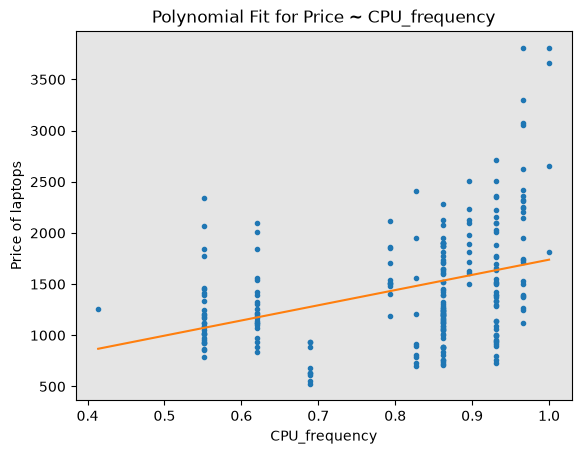

In [33]:
# Call for function of degree 1
PlotPolly(p1, x1, y1, 'CPU_frequency')

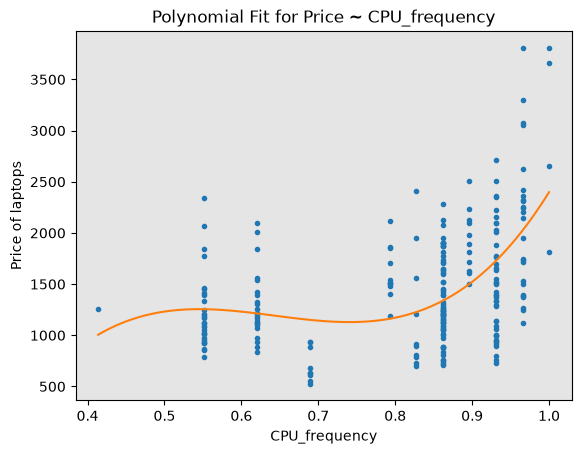

In [34]:
# Call for function of degree 3
PlotPolly(p3, x1, y1, 'CPU_frequency')

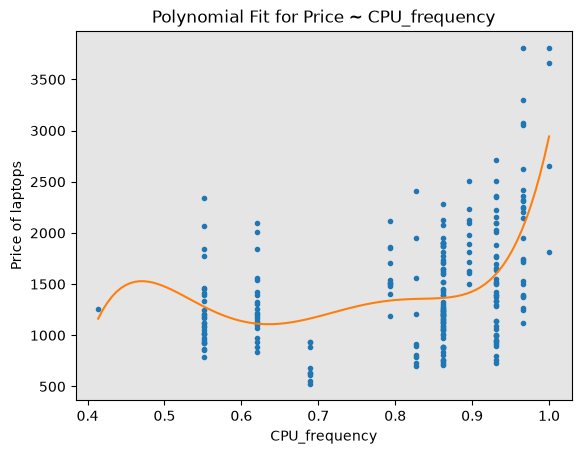

In [35]:
# Call for function of degree 5
PlotPolly(p5, x1, y1, 'CPU_frequency')

In [39]:
r_squared1 = r2_score(y1, p1(x1))
mse1 = mean_squared_error(y1, p1(x1))
print('The R2-squared value for 1st degree polynomial is:', r_squared1)
print('The (MSE) value for 1st degree polynomial is:', mse1)
r_squared3 = r2_score(y1, p3(x1))
mse3 = mean_squared_error(y1, p3(x1))
print('\nThe R2-squared value for 3rd degree polynomial is:', r_squared3)
print('The (MSE) value for 1st degree polynomial is:', mse3)
r_squared5 = r2_score(y1, p5(x1))
mse5 = mean_squared_error(y1, p5(x1))
print('\nThe R2-squared value for 5th degree polynomial is:', r_squared5)
print('The (MSE) value for 1st degree polynomial is:', mse5)

The R2-squared value for 1st degree polynomial is: 0.1344436321024326
The (MSE) value for 1st degree polynomial is: 284583.4405868629

The R2-squared value for 3rd degree polynomial is: 0.26692640796531086
The (MSE) value for 1st degree polynomial is: 241024.86303848776

The R2-squared value for 5th degree polynomial is: 0.3030822706443488
The (MSE) value for 1st degree polynomial is: 229137.29548054864


## Pipeline

In [41]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("polynomial", PolynomialFeatures()),
    ("model", LinearRegression())])
df_z = Z.astype(float)
pipeline.fit(df_z, df['Price'])
pipe_pred = pipeline.predict(df_z)

In [44]:
pipe_mse = mean_squared_error(df['Price'], pipe_pred)
pipe_r2 = r2_score(df['Price'], pipe_pred)

print(f"MSE for multi-variable polynomial pipeline is: {pipe_mse}\n\nOur model misses the target by: {pipe_mse**0.5:.3f}$ per laptop.")
print(f"\nR^2 for multi-variable polynomial pipeline is: {pipe_r2*100:.2f}%")

MSE for multi-variable polynomial pipeline is: 120595.86128028373

Our model misses the target by: 347.269$ per laptop.

R^2 for multi-variable polynomial pipeline is: 63.32%


## What I took away

- | Model | R² | Typical miss |
  |---|---|---|
  | CPU frequency, straight line | 13% | $533 |
  | CPU frequency, order 5 | 30% | $479 |
  | 7 columns, straight line | 51% | $402 |
  | 7 columns, pipeline with bends | 63% | $347 |
- More information about the laptop helped more than more bends on one column.
- All four are training-data scores. The order-5 curve bent to chase a single laptop.